In [154]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error

In [116]:
data = pd.read_csv("../energy_and_weather_data.csv",
                  parse_dates=["DateUTC"])

In [117]:
data = pd.merge(
    pd.get_dummies(data["weekday"]).astype(int), 
    data,
    left_index = True,
    right_index = True,
    how = "left"
)

In [118]:
data = data.drop(["weekday"], axis = 1)

In [119]:
X = data.drop(["Value", "DateUTC"], axis = 1)
y = data["Value"]

In [208]:
tss = TimeSeriesSplit(n_splits = 2, test_size = 2000, gap = 168)

In [209]:
y_pred = {}
y_true = {}
scores = []

In [210]:
for fold, (train_idx, test_idx) in enumerate(tss.split(X)):
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_test, y_test = X.iloc[test_idx], y.iloc[test_idx]
    model = DecisionTreeRegressor()
    model.fit(X_train, y_train)
    prediction = model.predict(X_test)
    y_pred[fold] = prediction
    y_true[fold] = y_test
    mse = mean_squared_error(y_test, prediction)
    print(mse)
    scores.append(mse)
    

25976.621815000002
21539.858784999997


In [123]:
data["DateUTC"] = pd.to_datetime(data["DateUTC"])

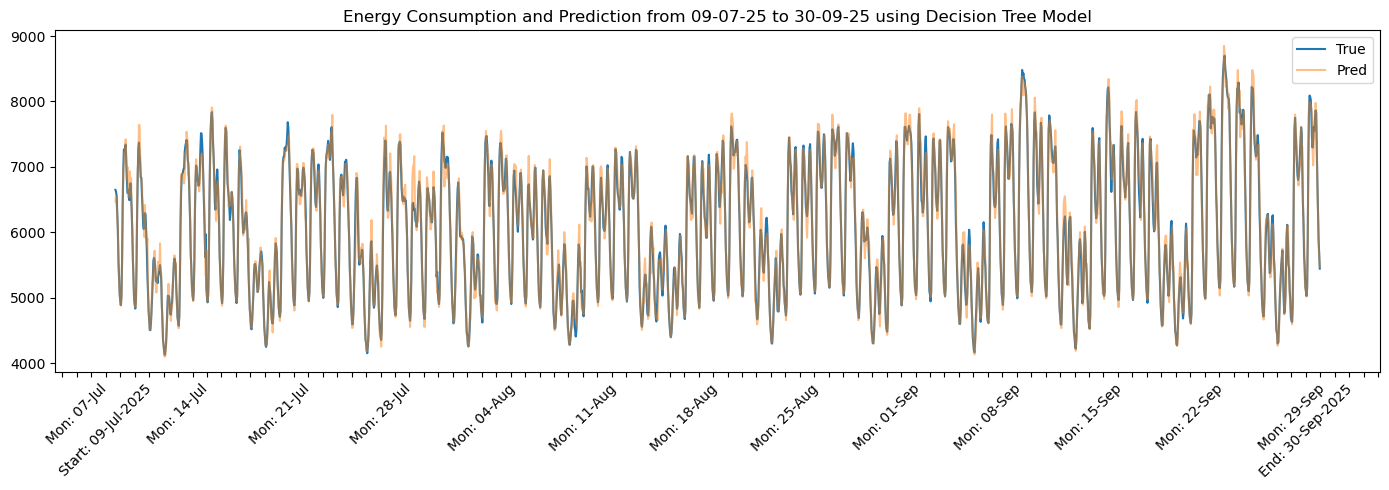

In [211]:
create_prediction_plot(y_true[1], y_pred[1], "Decision Tree")

In [197]:
def create_prediction_plot(y_true, y_pred, model_name):
    df = pd.DataFrame({
    "true": y_true,
    "pred": y_pred
    })
    dates = data.set_index("DateUTC")
    dates = dates.index[df.index]
    
    fig, ax = plt.subplots(figsize = (14,5))
    ax.plot(dates, df["true"], label = "True")
    ax.plot(dates, df["pred"], label = "Pred", alpha = 0.5)
    
    ax.xaxis.set_major_locator(mdates.DayLocator())
    
    def custom_formatter(x, pos):
        date = mdates.num2date(x)
        first = dates[0]
        last = dates[-1]
        if date.date() == first.date():
            return "Start: "+date.strftime("%d-%b-%Y")
        elif date.weekday() == 0:
            return "Mon: " + date.strftime("%d-%b")
        elif date.date() == last.date():
            return "End: " + date.strftime("%d-%b-%Y")
        else:
            return ""
    
    ax.xaxis.set_major_formatter(FuncFormatter(custom_formatter))
    
    plt.title(f"Energy Consumption and Prediction from {dates[0].strftime("%d-%m-%y")} to {dates[-1].strftime("%d-%m-%y")} using {model_name} Model")
    
    plt.xticks(rotation = 45)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [102]:
data.iloc[blub.index]["DateUTC"]

56978   2025-08-20 08:00:00
56979   2025-08-20 09:00:00
56980   2025-08-20 10:00:00
56981   2025-08-20 11:00:00
56982   2025-08-20 12:00:00
                ...        
57973   2025-09-30 19:00:00
57974   2025-09-30 20:00:00
57975   2025-09-30 21:00:00
57976   2025-09-30 22:00:00
57977   2025-09-30 23:00:00
Name: DateUTC, Length: 1000, dtype: datetime64[ns]